# Day 3 - Exploratory Data Analysis (EDA)

## Objectives

- Analyze NAV trends
- Study AUM growth
- Analyze SIP inflows
- Compare category inflows
- Study investor demographics
- Analyze folio growth
- Study portfolio allocation
- Generate insights for performance analytics

In [1]:
import sqlite3
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [2]:
conn = sqlite3.connect("../data/db/bluestock_mf.db")

In [3]:
fund_master = pd.read_sql("SELECT * FROM '01_fund_master'", conn)
nav_history = pd.read_sql("SELECT * FROM '02_nav_history'", conn)
aum = pd.read_sql("SELECT * FROM '03_aum_by_fund_house'", conn)
sip = pd.read_sql("SELECT * FROM '04_monthly_sip_inflows'", conn)
category = pd.read_sql("SELECT * FROM '05_category_inflows'", conn)
folio = pd.read_sql("SELECT * FROM '06_industry_folio_count'", conn)
performance = pd.read_sql("SELECT * FROM '07_scheme_performance'", conn)
transactions = pd.read_sql("SELECT * FROM '08_investor_transactions'", conn)
portfolio = pd.read_sql("SELECT * FROM '09_portfolio_holdings'", conn)
benchmark = pd.read_sql("SELECT * FROM '10_benchmark_indices'", conn)

In [4]:
print("Fund Master :", fund_master.shape)
print("NAV History :", nav_history.shape)
print("AUM :", aum.shape)
print("SIP :", sip.shape)
print("Category :", category.shape)
print("Folio :", folio.shape)
print("Performance :", performance.shape)
print("Transactions :", transactions.shape)
print("Portfolio :", portfolio.shape)
print("Benchmark :", benchmark.shape)

Fund Master : (40, 15)
NAV History : (46000, 3)
AUM : (90, 5)
SIP : (48, 6)
Category : (144, 3)
Folio : (21, 6)
Performance : (40, 19)
Transactions : (32778, 13)
Portfolio : (322, 8)
Benchmark : (8050, 3)


In [5]:
nav_history.head()


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [6]:
nav_history.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [7]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

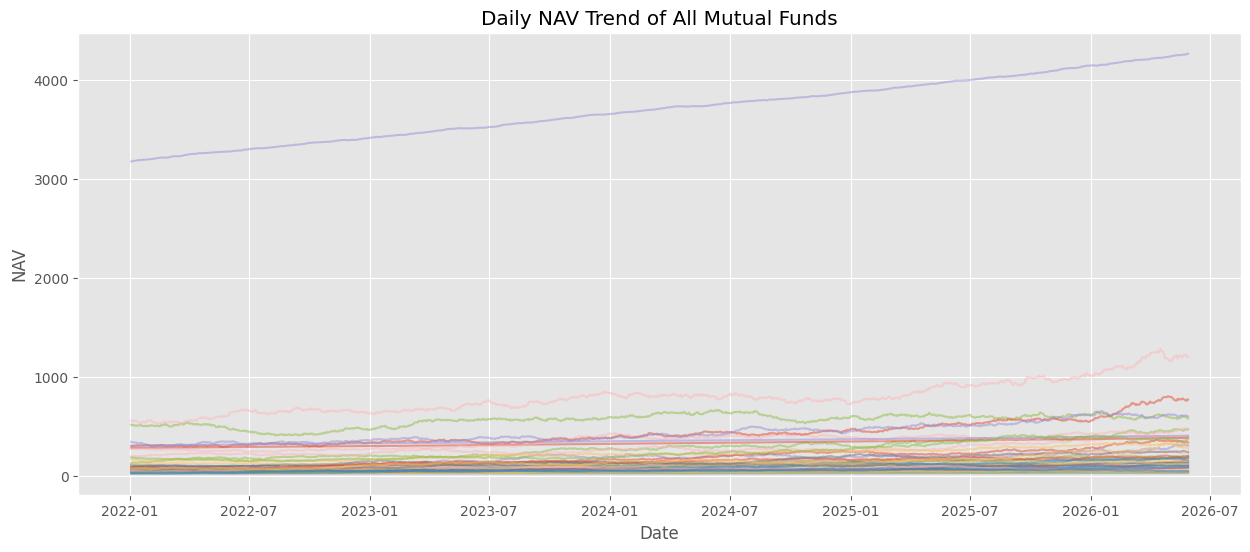

In [8]:
plt.figure(figsize=(15,6))

for code in nav_history["amfi_code"].unique():
    temp = nav_history[nav_history["amfi_code"] == code]
    plt.plot(temp["date"], temp["nav"], alpha=0.5)

plt.title("Daily NAV Trend of All Mutual Funds")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)
plt.show()

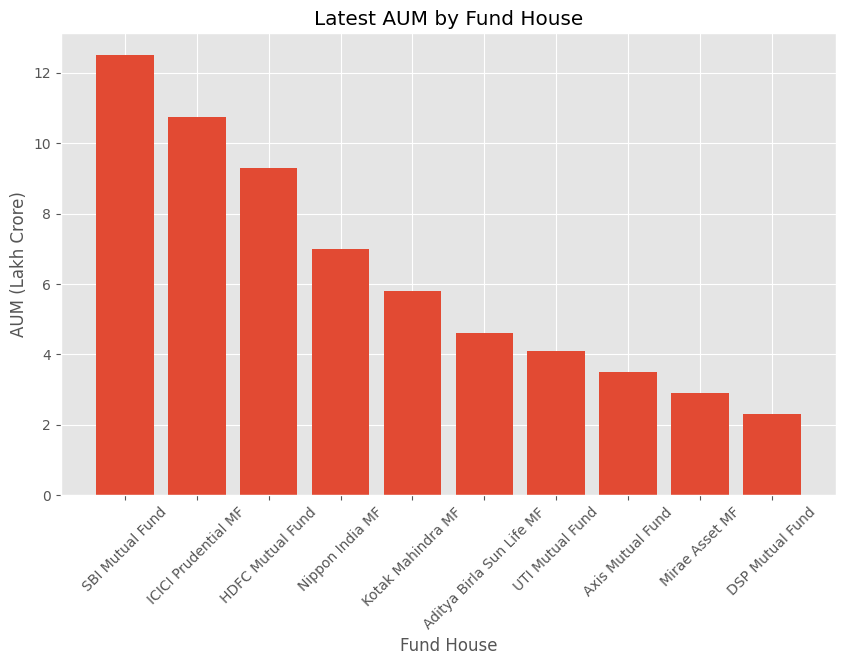

In [9]:
latest_date = aum["date"].max()

latest_aum = aum[aum["date"] == latest_date]

latest_aum = latest_aum.sort_values(
    "aum_lakh_crore",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.bar(
    latest_aum["fund_house"],
    latest_aum["aum_lakh_crore"]
)

plt.title("Latest AUM by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=45)

plt.show()

In [10]:
print(aum.columns.tolist())


['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


In [11]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [12]:
aum.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     str    
 1   fund_house      90 non-null     str    
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 3.6 KB


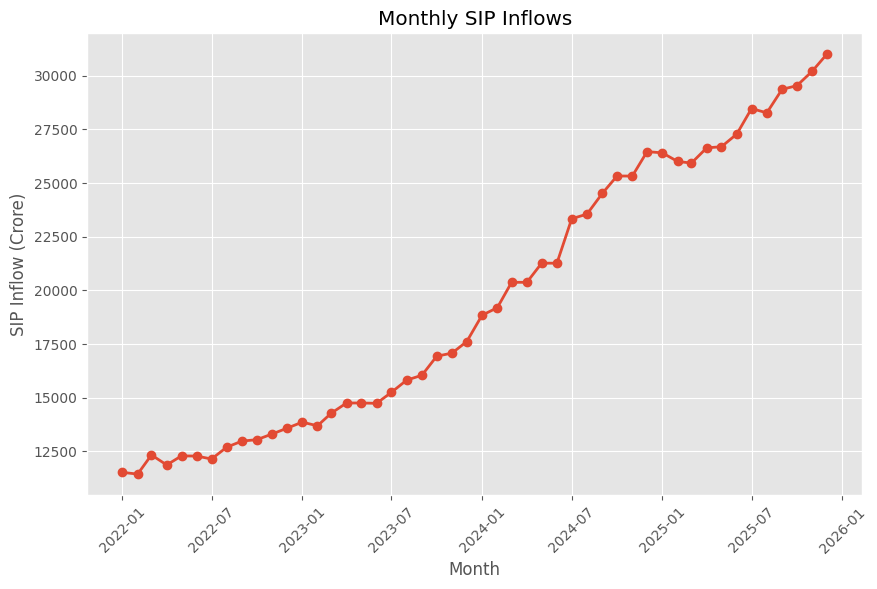

In [13]:
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(10,6))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o",
    linewidth=2
)

plt.title("Monthly SIP Inflows")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [14]:
print(sip.columns.tolist())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


In [15]:
print(category.columns.tolist())

['month', 'category', 'net_inflow_crore']


In [16]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [17]:
plt.figure(figsize=(12,7))

latest_category = latest_category.sort_values(
    "net_inflow_crore",
    ascending=True
)

plt.barh(
    latest_category["category"],
    latest_category["net_inflow_crore"],
    color="steelblue"
)

plt.title("Net Inflow by Mutual Fund Category")
plt.xlabel("Net Inflow (Crore)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

NameError: name 'latest_category' is not defined

<Figure size 1200x700 with 0 Axes>

In [ ]:
print(performance.columns.tolist())
performance.head()
performance.info()

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   scheme_name         40 non-null     str    
 2   fund_house          40 non-null     str    
 3   category            40 non-null     str    
 4   plan                40 non-null     str    
 5   return_1yr_pct      40 non-null     float64
 6   return_3yr_pct      40 non-null     float64
 7   return_5yr_pct      40 non-null     float64
 8   benchmark_3yr_pct   40 non-null     float64
 9   alpha               40 non-null     float64
 10  beta              

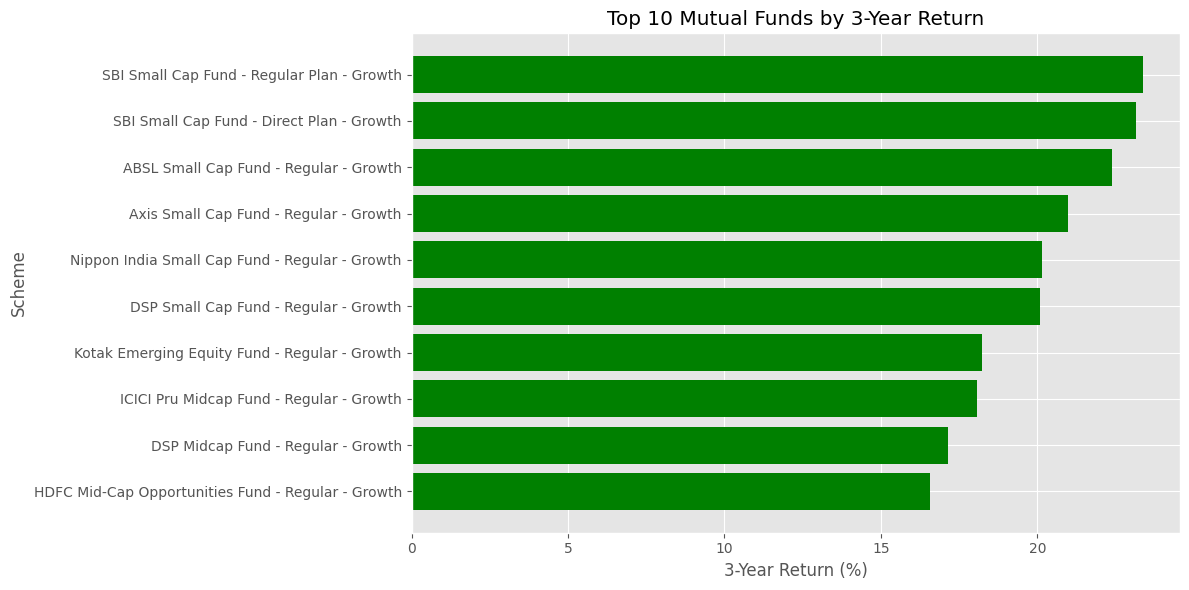

In [ ]:
plt.figure(figsize=(12,6))

top_returns = performance.sort_values(
    "return_3yr_pct",
    ascending=False
).head(10)

plt.barh(
    top_returns["scheme_name"],
    top_returns["return_3yr_pct"],
    color="green"
)

plt.title("Top 10 Mutual Funds by 3-Year Return")
plt.xlabel("3-Year Return (%)")
plt.ylabel("Scheme")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

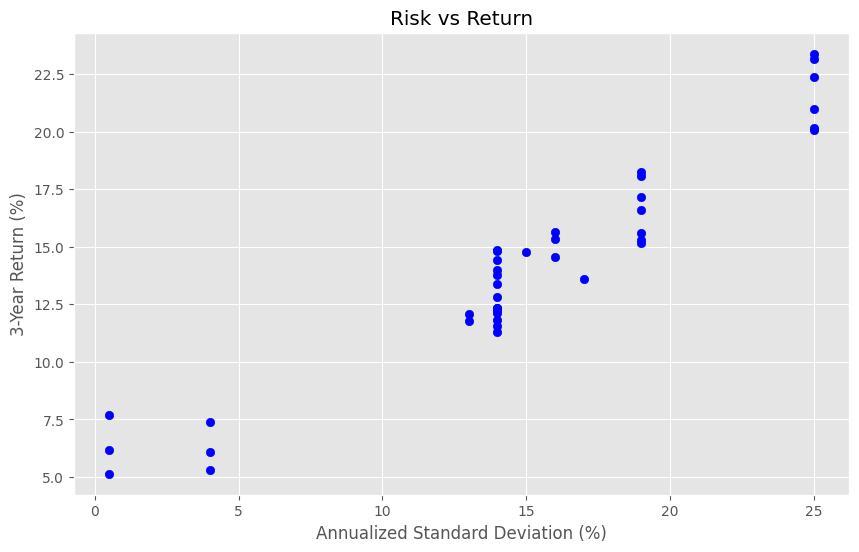

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    performance["std_dev_ann_pct"],
    performance["return_3yr_pct"],
    color="blue"
)

plt.title("Risk vs Return")
plt.xlabel("Annualized Standard Deviation (%)")
plt.ylabel("3-Year Return (%)")

plt.grid(True)

plt.show()

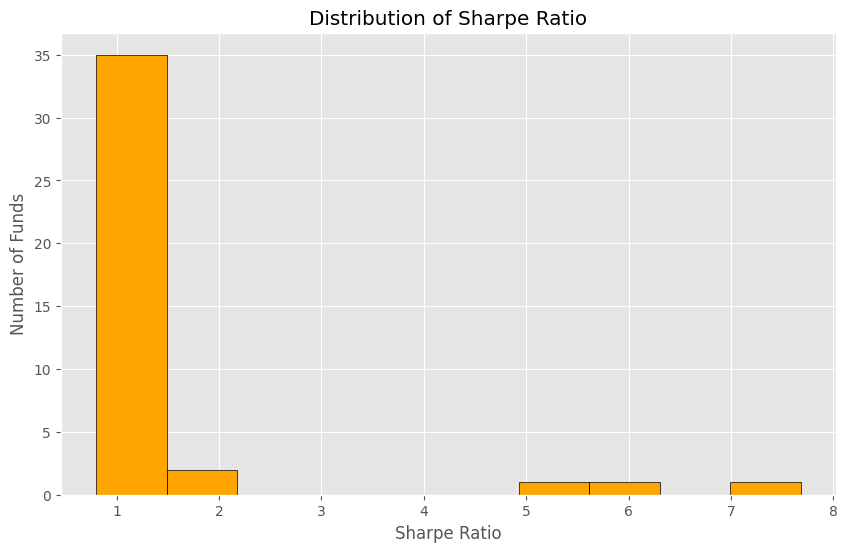

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    performance["sharpe_ratio"],
    bins=10,
    color="orange",
    edgecolor="black"
)

plt.title("Distribution of Sharpe Ratio")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Number of Funds")

plt.show()

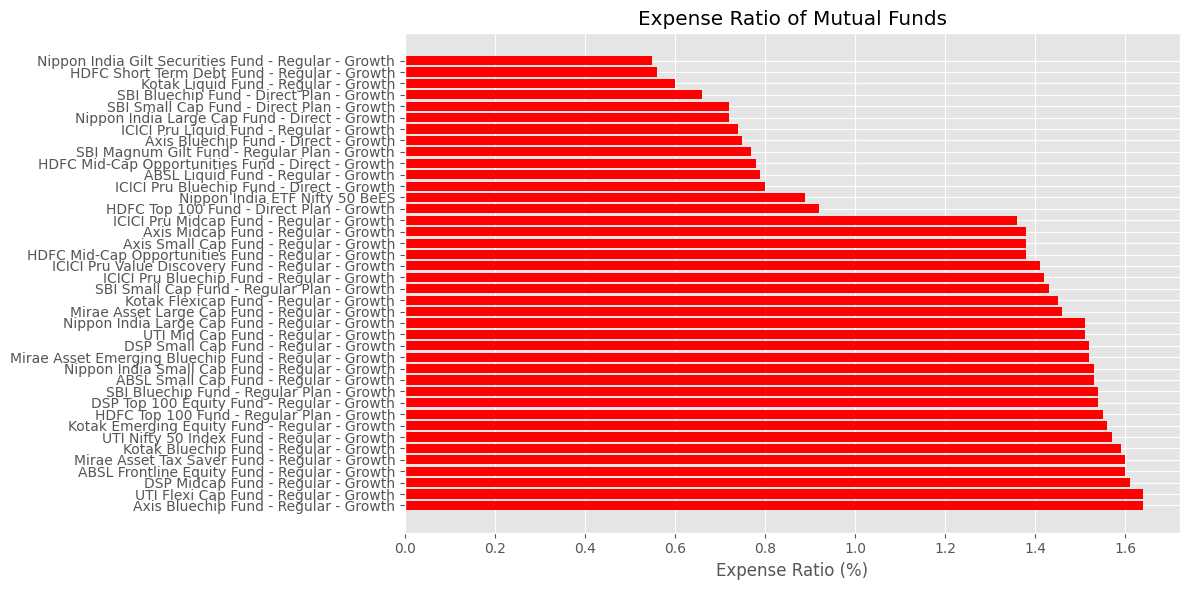

In [ ]:
plt.figure(figsize=(12,6))

expense = performance.sort_values(
    "expense_ratio_pct",
    ascending=False
)

plt.barh(
    expense["scheme_name"],
    expense["expense_ratio_pct"],
    color="red"
)

plt.title("Expense Ratio of Mutual Funds")
plt.xlabel("Expense Ratio (%)")

plt.tight_layout()
plt.show()

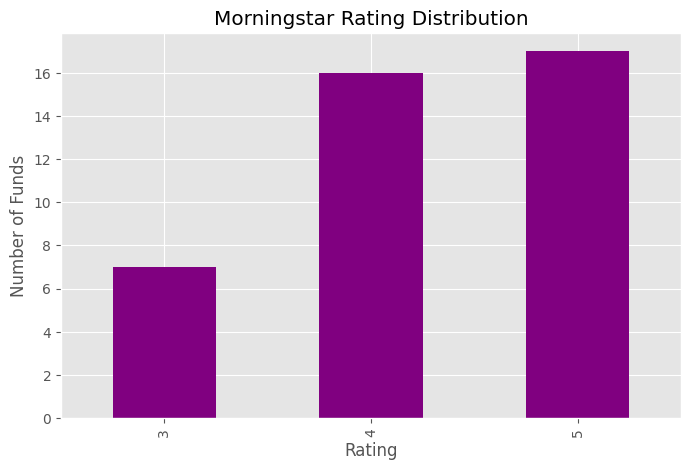

In [ ]:
plt.figure(figsize=(8,5))

performance["morningstar_rating"].value_counts().sort_index().plot(
    kind="bar",
    color="purple"
)

plt.title("Morningstar Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Funds")

plt.show()

In [ ]:
print(portfolio.columns.tolist())
portfolio.head()
portfolio.info()

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    str    
 2   stock_name         322 non-null    str    
 3   sector             322 non-null    str    
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    str    
dtypes: float64(3), int64(1), str(4)
memory usage: 20.3 KB


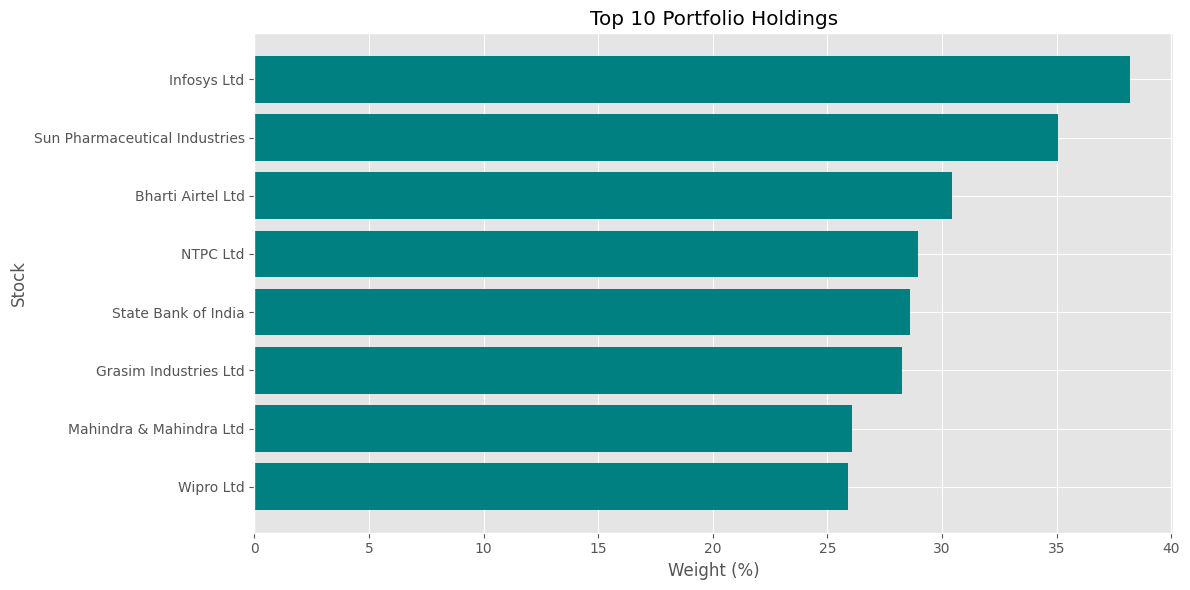

In [ ]:
plt.figure(figsize=(12,6))

top_holdings = portfolio.sort_values(
    "weight_pct",
    ascending=False
).head(10)

plt.barh(
    top_holdings["stock_name"],
    top_holdings["weight_pct"],
    color="teal"
)

plt.title("Top 10 Portfolio Holdings")
plt.xlabel("Weight (%)")
plt.ylabel("Stock")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

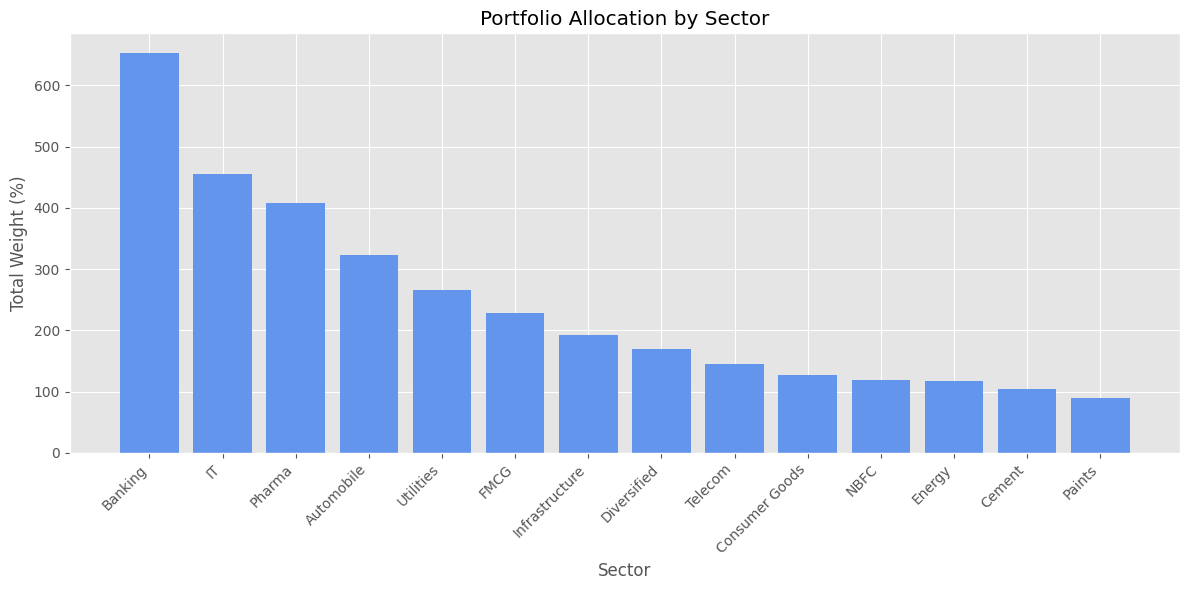

In [ ]:
plt.figure(figsize=(12,6))

sector_weight = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.bar(
    sector_weight.index,
    sector_weight.values,
    color="cornflowerblue"
)

plt.xticks(rotation=45, ha="right")

plt.title("Portfolio Allocation by Sector")
plt.xlabel("Sector")
plt.ylabel("Total Weight (%)")

plt.tight_layout()
plt.show()

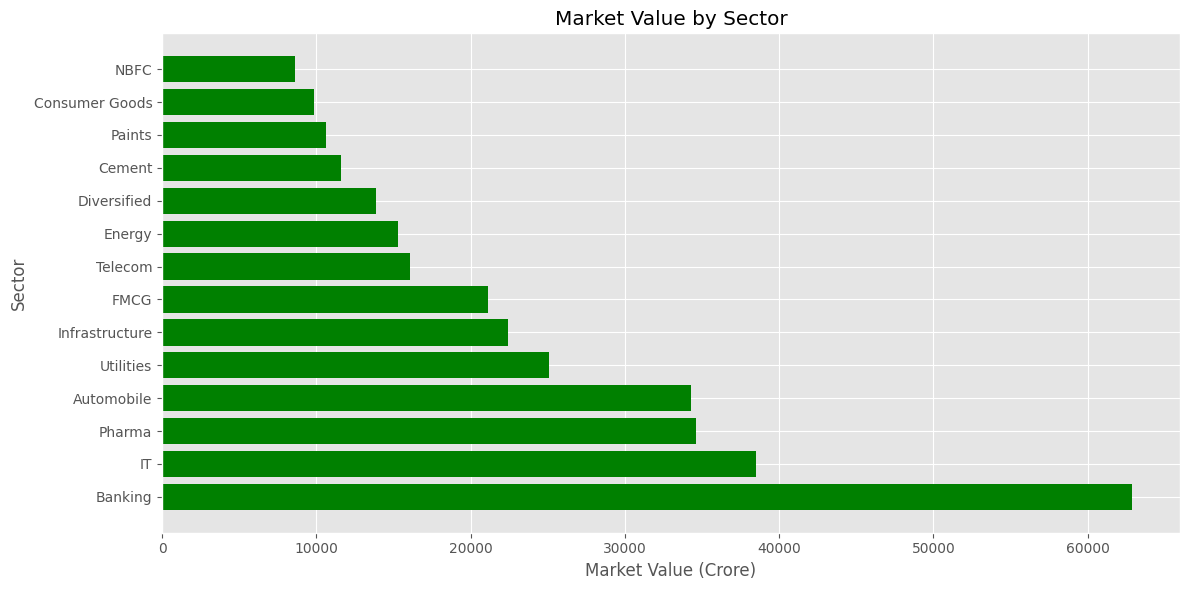

In [ ]:
plt.figure(figsize=(12,6))

market_sector = (
    portfolio.groupby("sector")["market_value_cr"]
    .sum()
    .sort_values(ascending=False)
)

plt.barh(
    market_sector.index,
    market_sector.values,
    color="green"
)

plt.title("Market Value by Sector")
plt.xlabel("Market Value (Crore)")
plt.ylabel("Sector")

plt.tight_layout()
plt.show()

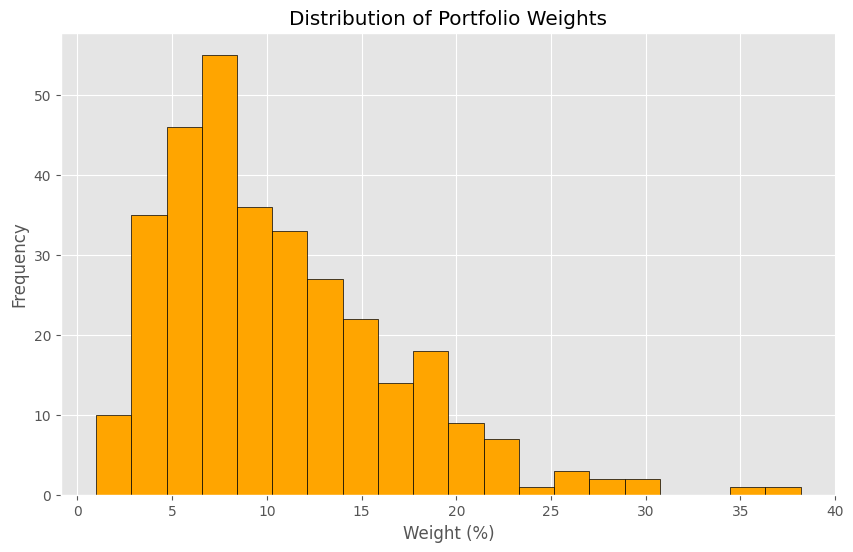

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    portfolio["weight_pct"],
    bins=20,
    color="orange",
    edgecolor="black"
)

plt.title("Distribution of Portfolio Weights")
plt.xlabel("Weight (%)")
plt.ylabel("Frequency")

plt.show()

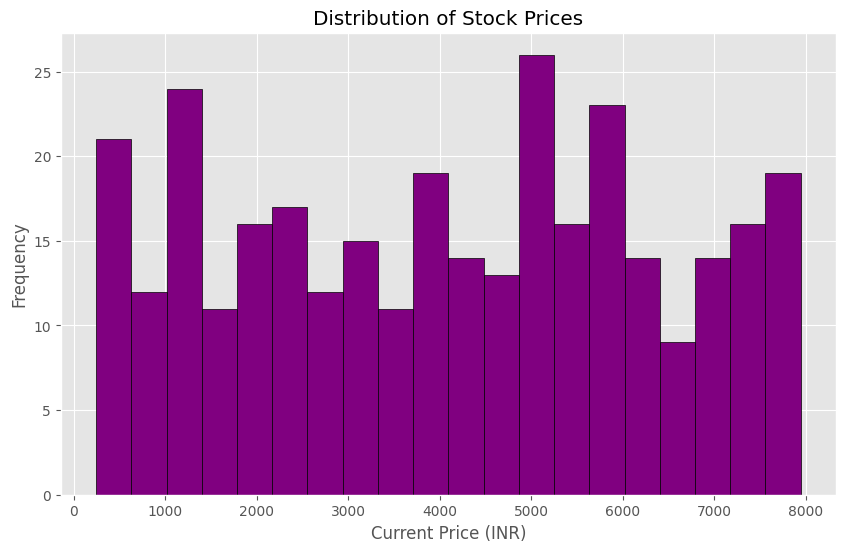

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    portfolio["current_price_inr"],
    bins=20,
    color="purple",
    edgecolor="black"
)

plt.title("Distribution of Stock Prices")
plt.xlabel("Current Price (INR)")
plt.ylabel("Frequency")

plt.show()

In [ ]:
print(transactions.columns.tolist())
transactions.head()
transactions.info()

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']
<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          327

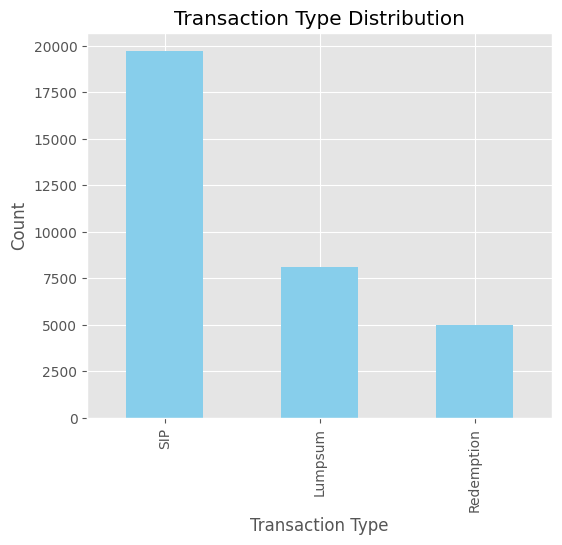

In [ ]:
plt.figure(figsize=(6,5))

transactions["transaction_type"].value_counts().plot(
    kind="bar",
    color="skyblue"
)

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.show()

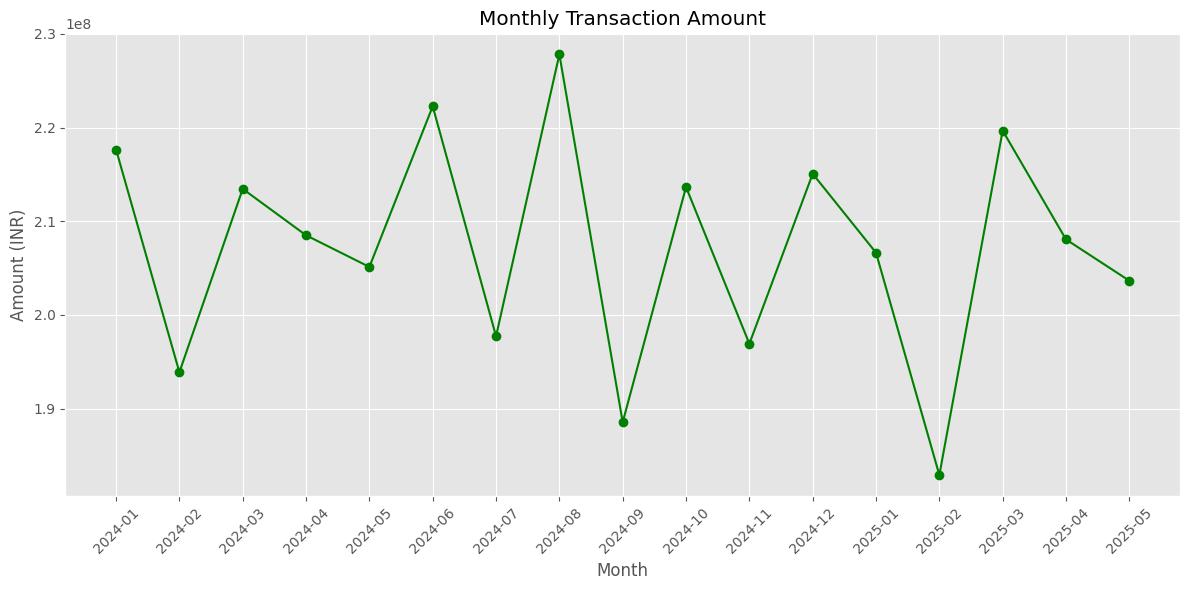

In [ ]:
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

monthly_txn = (
    transactions
    .groupby(transactions["transaction_date"].dt.to_period("M"))
    ["amount_inr"]
    .sum()
)

monthly_txn.index = monthly_txn.index.astype(str)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_txn.index,
    monthly_txn.values,
    marker="o",
    color="green"
)

plt.xticks(rotation=45)

plt.title("Monthly Transaction Amount")
plt.xlabel("Month")
plt.ylabel("Amount (INR)")

plt.tight_layout()
plt.show()

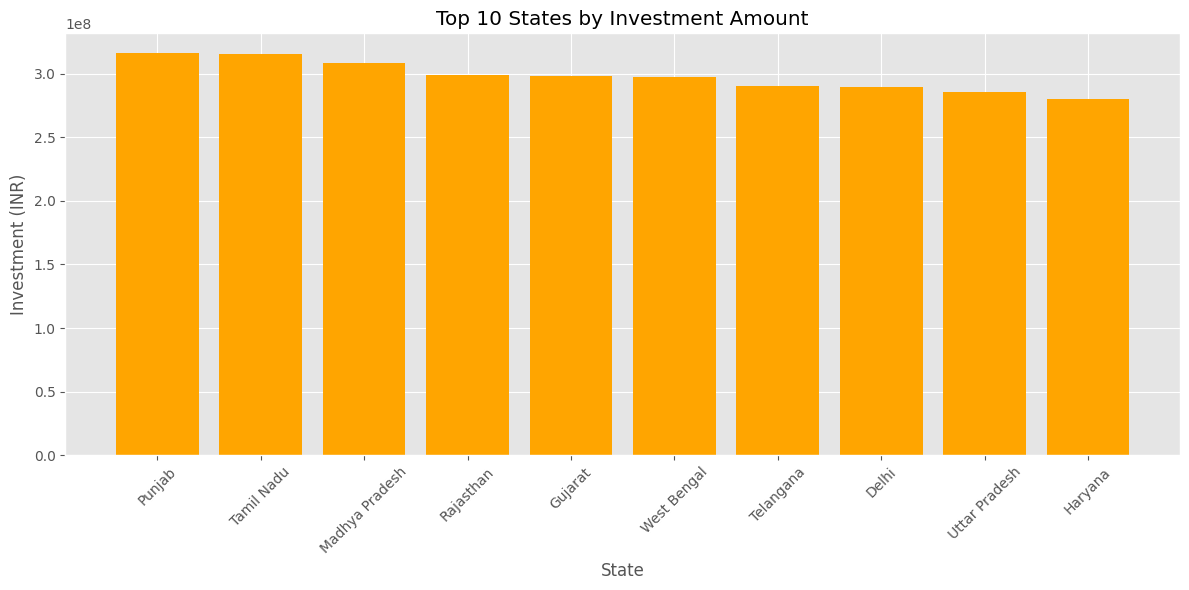

In [ ]:
plt.figure(figsize=(12,6))

state_amt = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.bar(
    state_amt.index,
    state_amt.values,
    color="orange"
)

plt.xticks(rotation=45)

plt.title("Top 10 States by Investment Amount")
plt.xlabel("State")
plt.ylabel("Investment (INR)")

plt.tight_layout()
plt.show()

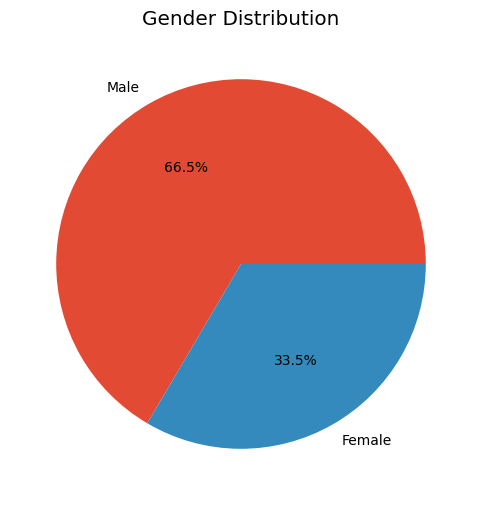

In [ ]:
plt.figure(figsize=(6,6))

transactions["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Gender Distribution")

plt.show()

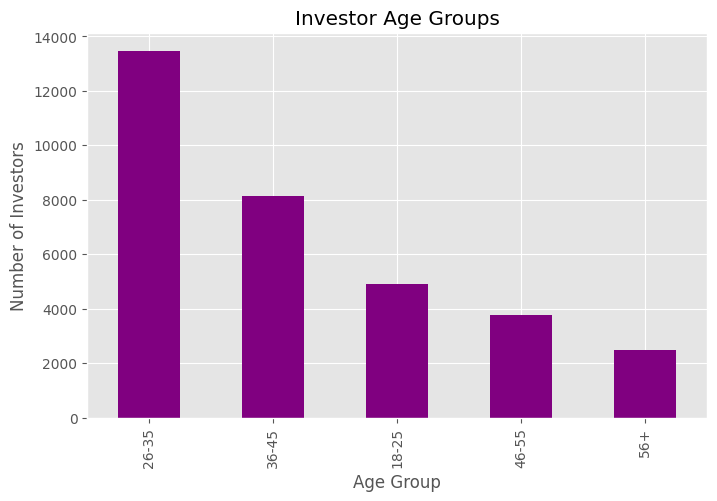

In [ ]:
plt.figure(figsize=(8,5))

transactions["age_group"].value_counts().plot(
    kind="bar",
    color="purple"
)

plt.title("Investor Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Investors")

plt.show()

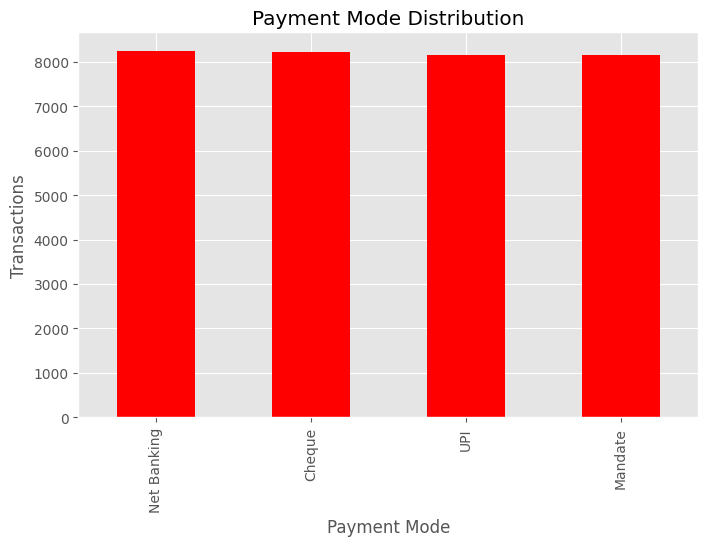

In [ ]:
plt.figure(figsize=(8,5))

transactions["payment_mode"].value_counts().plot(
    kind="bar",
    color="red"
)

plt.title("Payment Mode Distribution")
plt.xlabel("Payment Mode")
plt.ylabel("Transactions")

plt.show()

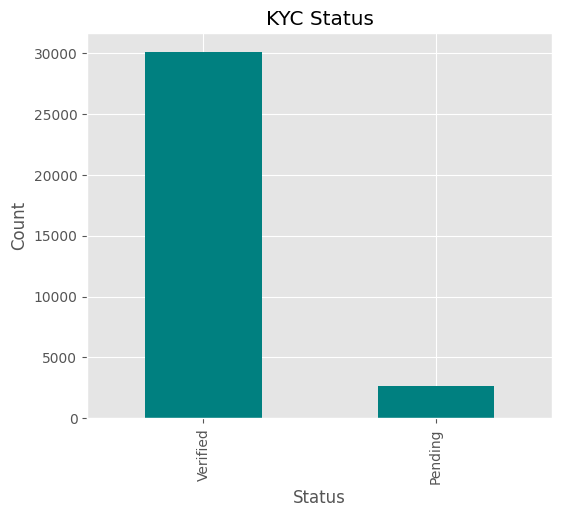

In [ ]:
plt.figure(figsize=(6,5))

transactions["kyc_status"].value_counts().plot(
    kind="bar",
    color="teal"
)

plt.title("KYC Status")
plt.xlabel("Status")
plt.ylabel("Count")

plt.show()